In [13]:
from google.colab import files
uploaded = files.upload()




Saving test_FD001.txt to test_FD001.txt


In [14]:
import pandas as pd

column_names = ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]

df = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=column_names)

df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [15]:
df[['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5']].describe()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5
count,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04
mean,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01
std,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12
min,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01
25%,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01
50%,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01
75%,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01
max,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01


In [16]:
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
df[sensor_cols].std()

,0
sensor_1,6.537152e-11
sensor_2,5.000533e-01
sensor_3,6.131150e+00
sensor_4,9.000605e+00
sensor_5,3.394700e-12
sensor_6,1.388985e-03
sensor_7,8.850923e-01
sensor_8,7.098548e-02
sensor_9,2.208288e+01
sensor_10,4.660829e-13


In [17]:
dead_sensors = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
df = df.drop(columns=dead_sensors)
df.head()


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


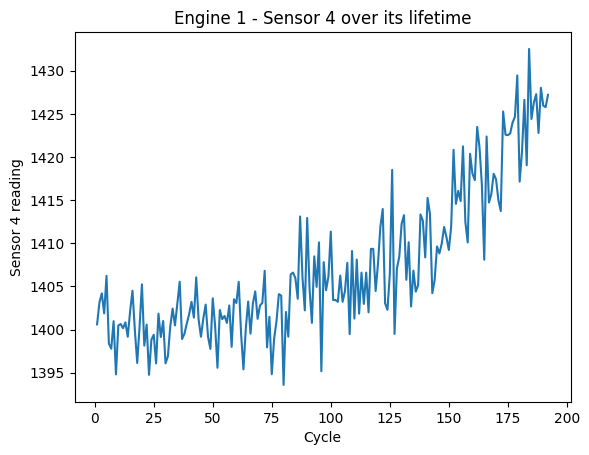

In [18]:
import matplotlib.pyplot as plt

engine_1 = df[df['engine_id'] == 1]

plt.plot(engine_1['cycle'], engine_1['sensor_4'])
plt.xlabel('Cycle')
plt.ylabel('Sensor 4 reading')
plt.title('Engine 1 - Sensor 4 over its lifetime')
plt.show()


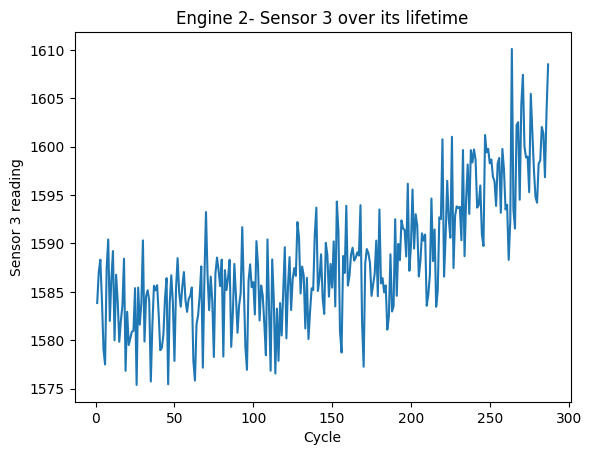

In [19]:
import matplotlib.pyplot as plt

engine_2 = df[df['engine_id'] == 2]

plt.plot(engine_2['cycle'], engine_2['sensor_3'])
plt.xlabel('Cycle')
plt.ylabel('Sensor 3 reading')
plt.title('Engine 2- Sensor 3 over its lifetime')
plt.show()

In [20]:
max_cycle = df.groupby('engine_id')['cycle'].max()

df = df.merge(max_cycle, on='engine_id', suffixes=('', '_max'))

df['RUL'] = df['cycle_max'] - df['cycle']

df = df.drop(columns=['cycle_max'])

df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


In [21]:
df[df['engine_id'] == 1][['cycle', 'RUL']].tail()

,cycle,RUL
187,188,4
188,189,3
189,190,2
190,191,1
191,192,0


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

feature_cols = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
                'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
                'sensor_17', 'sensor_20', 'sensor_21']

X = df[feature_cols]
y = df['RUL']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: {mae:.2f} cycles")

Mean Absolute Error: 29.51 cycles


In [23]:
baseline_prediction = y_train.mean()
baseline_mae = mean_absolute_error(y_test, [baseline_prediction] * len(y_test))
print(f"Baseline (always guess average) MAE: {baseline_mae:.2f} cycles")

Baseline (always guess average) MAE: 55.63 cycles


In [24]:
df = df.sort_values(['engine_id', 'cycle'])

rolling_features = []
for col in feature_cols:
    new_col = f'{col}_rollmean'
    df[new_col] = df.groupby('engine_id')[col].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
    rolling_features.append(new_col)

df[['engine_id', 'cycle', 'sensor_4', 'sensor_4_rollmean']].head(10)

,engine_id,cycle,sensor_4,sensor_4_rollmean
0,1,1,1400.60,1400.600000
1,1,2,1403.14,1401.870000
2,1,3,1404.20,1402.646667
3,1,4,1401.87,1402.452500
4,1,5,1406.22,1403.206000
5,1,6,1398.37,1402.760000
6,1,7,1397.77,1401.686000
7,1,8,1400.97,1401.040000
8,1,9,1394.80,1399.626000
9,1,10,1400.46,1398.474000


In [25]:
X_rolling = df[rolling_features]
y = df['RUL']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_rolling, y, test_size=0.2, random_state=42)

model2 = RandomForestRegressor(n_estimators=100, random_state=42)
model2.fit(X_train2, y_train2)

predictions2 = model2.predict(X_test2)

mae2 = mean_absolute_error(y_test2, predictions2)
print(f"MAE with rolling averages: {mae2:.2f} cycles")
print(f"MAE with raw sensors (previous): 29.51 cycles")

MAE with rolling averages: 22.86 cycles
MAE with raw sensors (previous): 29.51 cycles


In [26]:
df['RUL'] = df['RUL'].clip(upper=125)

X_rolling = df[rolling_features]
y = df['RUL']

X_train3, X_test3, y_train3, y_test3 = train_test_split(X_rolling, y, test_size=0.2, random_state=42)

model3 = RandomForestRegressor(n_estimators=100, random_state=42)
model3.fit(X_train3, y_train3)

predictions3 = model3.predict(X_test3)
mae3 = mean_absolute_error(y_test3, predictions3)
print(f"MAE with capped RUL: {mae3:.2f} cycles")

MAE with capped RUL: 10.54 cycles


In [27]:
model4 = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
model4.fit(X_train3, y_train3)

predictions4 = model4.predict(X_test3)
mae4 = mean_absolute_error(y_test3, predictions4)
print(f"MAE with tuned model: {mae4:.2f} cycles")

MAE with tuned model: 10.77 cycles


In [28]:
import joblib

joblib.dump(model3, 'bearing_model.pkl')

from google.colab import files
files.download('bearing_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
model_small = RandomForestRegressor(n_estimators=50, random_state=42)
model_small.fit(X_train3, y_train3)

predictions_small = model_small.predict(X_test3)
mae_small = mean_absolute_error(y_test3, predictions_small)
print(f"MAE with 50 trees: {mae_small:.2f} cycles")

joblib.dump(model_small, 'bearing_model_small.pkl')

import os
print(f"File size: {os.path.getsize('bearing_model_small.pkl') / (1024*1024):.2f} MB")

MAE with 50 trees: 10.56 cycles
File size: 42.29 MB


In [30]:
model_small = RandomForestRegressor(n_estimators=100, random_state=42)
model_small.fit(X_train3, y_train3)

predictions_small = model_small.predict(X_test3)
mae_small = mean_absolute_error(y_test3, predictions_small)
print(f"MAE with 100 trees: {mae_small:.2f} cycles")

joblib.dump(model_small, 'bearing_model_small.pkl')

import os
print(f"File size: {os.path.getsize('bearing_model_small.pkl') / (1024*1024):.2f} MB")

MAE with 100 trees: 10.54 cycles
File size: 84.56 MB
